# Notebook 2 — plot saved entropies and fit averaged entropy

Loads the saved `.npz`, plots all individual disorder entropy curves, plots the averaged entropy on top, and draws a tunable linear CFT fit in the chosen `ell_min ... ell_max` interval.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 200,
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 12,
})



data_file = Path("entropy_batches_Hubbard/points_lifshitz1_entropy_batches_Hubbard_PBC_chi_100.npz")
data_file = Path("entropy_batches_Hubbard/points_gapped_entropy_batches_Hubbard_PBC_chi_100.npz")
data_file = Path("entropy_batches_Hubbard/points_localization_entropy_batches_Hubbard_PBC_chi_100.npz")


data = np.load(data_file, allow_pickle=True)

ell_grid = data["ell_grid"]
S_samples = data["S_samples"]
S_avg = data["S_avg"]
L = int(data["L"])
W = float(data["W"])
g = float(data["g"])
chi_max = int(data["chi_max"])
max_sweeps = int(data["max_sweeps"])
n_done = int(data["n_done"])
n_success = int(data["n_success"])

#data_file = Path("entropy_batches_fully_critical/entropy_batches_fully_critical_chi_40.npz")
#data20 = np.load(data_file, allow_pickle=True)
#S_samples = np.abs(data20["S_samples"]-S_samples)
#S_avg = np.abs(data20["S_avg"]-S_avg)

print("Loaded:", data_file)
print("S_samples shape:", S_samples.shape)
print("S_avg shape:", S_avg.shape)
print("n_success:", n_success)

Loaded: entropy_batches_fully_critical/points_localization2_entropy_batches_fully_critical_PBC_chi_100.npz
S_samples shape: (1000, 125)
S_avg shape: (125,)
n_success: 1000


In [40]:
# ============================================================
# Tunable plotting / fitting parameters
# ============================================================

ell_min = 40
ell_max = 120

# "cft" plots S versus x = 1/6 log[(2L/pi)sin(pi ell/L)]
# "ell" plots S versus ell
x_axis_mode = "cft"

plot_individual_curves = True
max_individual_curves = None  # None: plot all. Use e.g. 300 for very many samples.
individual_alpha = 0.18
individual_lw = 0.35

save_figure = True
figure_file = data_file.parent / f"entropy_fit_ell_{ell_min}_{ell_max}.png"

In [41]:
def x_cft_obc(ell, L):
    ell = np.asarray(ell, dtype=float)
    return (1.0 / 3.0) * np.log((2.0 * L / np.pi) * np.sin(np.pi * ell / L))

def fit_c_from_avg_entropy(ell_grid, S_avg, L, ell_min, ell_max):
    ell_grid = np.asarray(ell_grid, dtype=int)
    S_avg = np.asarray(S_avg, dtype=float)
    ell_max_eff = min(int(ell_max), int(np.max(ell_grid)), L // 2)
    mask = (ell_grid >= int(ell_min)) & (ell_grid <= ell_max_eff) & np.isfinite(S_avg)
    if np.count_nonzero(mask) < 2:
        return np.nan, np.nan, mask
    x = x_cft_obc(ell_grid[mask], L)
    y = S_avg[mask]
    good = np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(good) < 2:
        return np.nan, np.nan, mask
    c, s0 = np.polyfit(x[good], y[good], 1)
    return float(c), float(s0), mask

def get_x_for_plot(ell_grid, L, mode):
    if mode == "ell":
        return np.asarray(ell_grid, dtype=float), r"$\ell$"
    if mode == "cft":
        return x_cft_obc(ell_grid, L), r"$\frac{1}{6}\ln\left[\frac{2L}{\pi}\sin\left(\pi\ell/L\right)\right]$"
    raise ValueError("x_axis_mode must be 'ell' or 'cft'")

Saved figure: entropy_batches_fully_critical/entropy_fit_ell_40_120.png


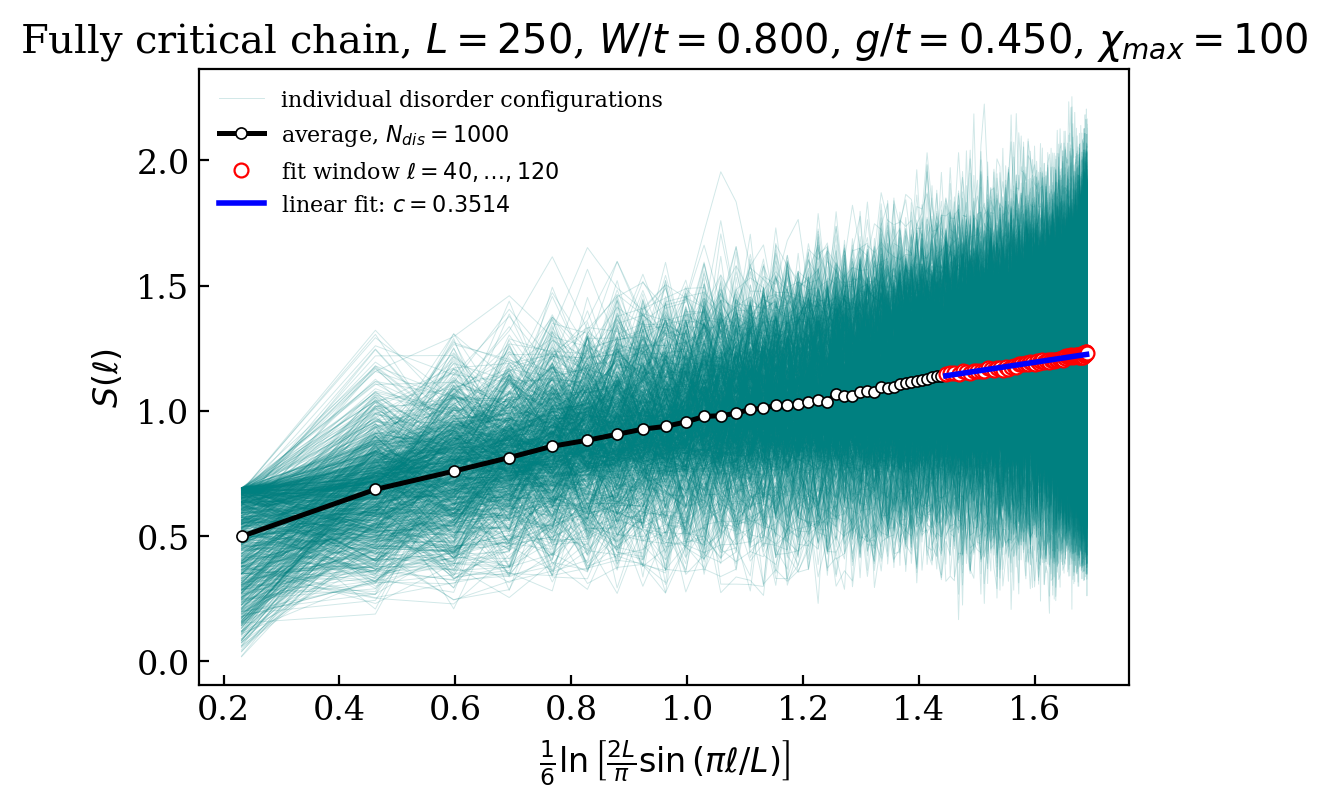

ell_min = 40
ell_max = 120
c_fit  = 0.3514037744208464
intercept = 0.6317067263879506


In [ ]:
c_fit, intercept, fit_mask = fit_c_from_avg_entropy(ell_grid, S_avg, L, ell_min, ell_max)
x_plot, x_label = get_x_for_plot(ell_grid, L, x_axis_mode)

ell_smooth = np.linspace(max(ell_min, int(np.min(ell_grid))), min(ell_max, int(np.max(ell_grid)), L // 2), 400)
x_smooth_cft = x_cft_obc(ell_smooth, L)
S_fit_line = c_fit * x_smooth_cft + intercept
x_smooth_plot = ell_smooth if x_axis_mode == "ell" else x_smooth_cft

fig, ax = plt.subplots(figsize=(5.7, 4.2), dpi=200)

if plot_individual_curves:
    if max_individual_curves is None:
        indices = np.arange(len(S_samples))
    else:
        indices = np.linspace(0, len(S_samples)-1, min(max_individual_curves, len(S_samples)), dtype=int)
    for k, j in enumerate(indices):
        ax.plot(x_plot, S_samples[j], lw=individual_lw, alpha=individual_alpha, color="teal",
                label="individual disorder configurations" if k == 0 else None)

ax.plot(x_plot, S_avg, "o-", ms=4, lw=1.8, color="black", mfc="white", mec="black", mew=0.6,
        label=rf"average, $N_{{dis}}={n_success}$")
ax.plot(x_plot[fit_mask], S_avg[fit_mask], "o", ms=5, color="red", mfc="white", mec="red", mew=0.8,
        label=rf"fit window $\ell={ell_min},\ldots,{ell_max}$")

# Linear fit line, drawn only in the selected ell-domain.
ax.plot(x_smooth_plot, S_fit_line, "-", lw=2.0, color="blue", label=rf"linear fit: $c={c_fit:.4f}$")

ax.set_xlabel(x_label)
ax.set_ylabel(r"$S(\ell)$")
ax.set_title(rf"Majorana-Hubbard chain, $L={L}$, $W/t={W:.3f}$, $g/t={g:.3f}$, $\chi_{{max}}={chi_max}$")
ax.legend(frameon=False, fontsize=8)
ax.tick_params(direction="in")
plt.tight_layout()
if save_figure:
    fig.savefig(figure_file, bbox_inches="tight", dpi=300)
    print("Saved figure:", figure_file)
plt.show()

print("ell_min =", ell_min)
print("ell_max =", ell_max)
print("c_fit  =", c_fit)
print("intercept =", intercept)

In [13]:
# Optional: save the refitted central charge for the chosen fitting window
fit_output_file = data_file.parent / f"central_charge_from_avg_entropy_ell_{ell_min}_{ell_max}.npz"
np.savez_compressed(
    fit_output_file,
    c_fit=float(c_fit),
    intercept=float(intercept),
    ell_min=int(ell_min),
    ell_max=int(ell_max),
    L=int(L),
    W=float(W),
    g=float(g),
    n_success=int(n_success),
    chi_max=int(chi_max),
    max_sweeps=int(max_sweeps),
)
print("Saved fit result:", fit_output_file)

Saved fit result: entropy_batches_fully_critical/central_charge_from_avg_entropy_ell_10_80.npz
